0.0


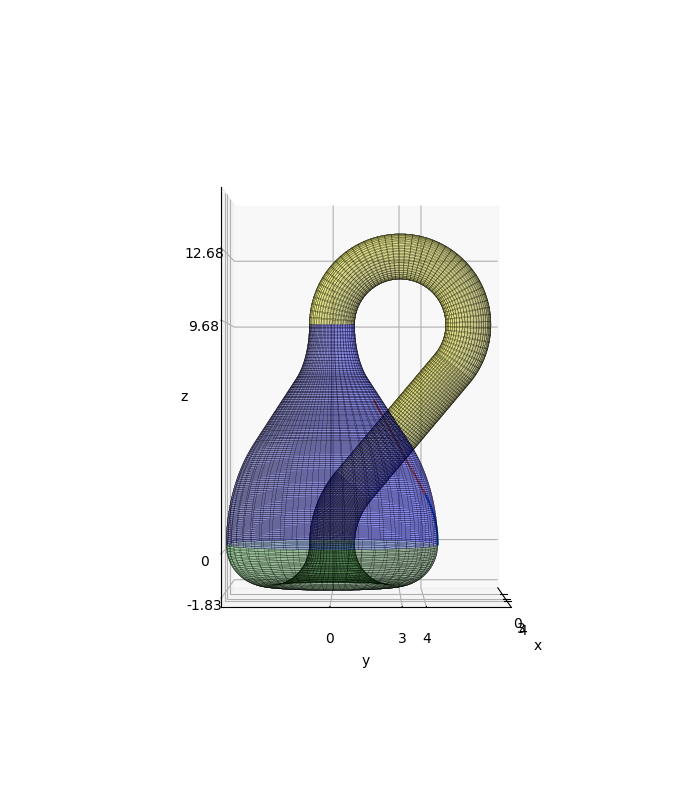

In [10]:

import numpy as np

import matplotlib.pyplot as plt
%matplotlib ipympl

#Rounding
dp=2

#Parameters
a = 3
b = 4
c = 7
p = 1
theta = .7
phi = .5
alpha = 0

h = (a+b+(a-b)*np.cos(theta))/np.sin(theta)
d = (p*np.sin(phi)*np.sin(alpha)+p-h*np.sin(phi)*np.cos(alpha)+c*np.cos(alpha)-(p+c)*np.cos(phi)*np.cos(alpha))/(np.sin(phi)*np.sin(alpha)+np.cos(alpha)+1)

P = np.array([0,a*(1+np.cos(theta)),h-a*np.sin(theta)])
Q = np.array([0,b*(1-np.cos(theta)),b*np.sin(theta)])
PQ = Q-P
magPQ = np.sqrt(PQ[1]**2+PQ[2]**2)
PQhat = PQ/magPQ

C=np.array([0,0,(p-d)*np.tan(alpha)])
Z=np.array([0,p-d-d*np.cos(alpha),d*np.sin(alpha)])
CZ=Z-C
magCZ = np.sqrt(CZ[1]**2+CZ[2]**2)
print(magCZ-(p-d)/np.cos(alpha)+d)

X = np.array([0,((p-d)/np.cos(alpha)-d)*np.cos(phi),(p-d)*np.tan(alpha) + ((p-d)/np.cos(alpha)-d)*np.sin(phi)])
Y = np.array([0,p+c-c*np.cos(phi),h-c*np.sin(phi)])

#Figure
fig = plt.figure(figsize = (7,8), label = ' ')
fig.tight_layout()
ax = plt.axes(projection='3d')

#Bottle 1
u = np.linspace(d*np.sin(alpha), X[2], 50)
ax.plot(0,np.sqrt( ((p-d)/np.cos(alpha)-d)**2-(u-(p-d)*np.tan(alpha))**2 ),u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)

#Diretrix
gamma = (0,0,u)

#ON Frame
T = (0,0,1)
N = (1,0,0)
B = (0,1,0)

#Radius function
r = np.sqrt( ((p-d)/np.cos(alpha)-d)**2-(u-(p-d)*np.tan(alpha))**2 )
#r = np.sqrt(magCZ**2-(u-(p-d)*np.tan(alpha))**2)
rdot = -(u-(p-d)*np.tan(alpha))/np.sqrt(((p-d)/np.cos(alpha)-d)**2-(u-(p-d)*np.tan(alpha))**2 )

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'blue', edgecolor = 'black', linewidth = .1, alpha = .25)


#Bottle 2
u = np.linspace((p-d)*np.tan(alpha)+magCZ*np.sin(phi), h-c*np.sin(phi), 40)
ax.plot(0,h*np.tan(phi)-c/np.cos(phi)+(p+c)-u*np.tan(phi),u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)

#Diretrix
gamma = (0,0,u)

#ON Frame
T = (0,0,1)
N = (1,0,0)
B = (0,1,0)

#Radius function
r = h*np.tan(phi)-c/np.cos(phi)+(p+c)-u*np.tan(phi)
rdot = -np.tan(phi)

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'blue', edgecolor = 'black', linewidth = .1, alpha = .25)

#Bottle 3
u = np.linspace(h-c*np.sin(phi), h, 20)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)

#Diretrix
gamma = (0,0,u)

#ON Frame
T = (0,0,1)
N = (1,0,0)
B = (0,1,0)

#Radius function
r = p+c-np.sqrt(c**2-(u-h)**2)
rdot = (u-h)/np.sqrt(c**2-(u-h)**2)

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'blue', edgecolor = 'black', linewidth = .1, alpha = .25)


#Handle 1
u = np.linspace(0, a*(np.pi+theta), 100)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)

#Diretrix
gamma = (0,a*(1+np.cos(np.pi-u/a)),h+a*np.sin(np.pi-u/a))

#ON Frame
T = (0,-np.sin(np.pi-u/a),np.cos(np.pi-u/a))
N = (0,-np.cos(np.pi-u/a),-np.sin(np.pi-u/a))
B = (1,0,0)

#Radius function
r = p
rdot = 0

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'yellow', edgecolor = 'black', linewidth = .1, alpha = .25)

#Handle 2
u = np.linspace(0, magPQ, 50)
v = np.linspace(0,2*np.pi,50)
u, v = np.meshgrid(u, v)

#Diretrix
gamma = (0, (u/magPQ)*Q[1] + (1-u/magPQ)*P[1], (u/magPQ)*Q[2] + (1-u/magPQ)*P[2])
#ax.plot(0,(u/magPQ)*Q[0] + (1-u/magPQ)*P[0], (u/magPQ)*Q[1] + (1-u/magPQ)*P[1], (u/magPQ)*Q[2] + (1-u/magPQ)*P[2])

#ON Frame
T = (0,PQhat[1],PQhat[2])
N = (0,PQhat[2],-PQhat[1])
B = (1,0,0)

#Radius function
r = p
rdot = 0

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'yellow', edgecolor = 'black', linewidth = .1, alpha = .25)

#Handle 3
u = np.linspace(0, b*theta, 100)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)

#Diretrix
gamma = (0,b+b*np.cos(np.pi-theta+u/b), b*np.sin(np.pi-theta+u/b))

#ON Frame
T = (0,-np.sin(np.pi-theta+u/b),np.cos(np.pi-theta+u/b))
N = (0,-np.cos(np.pi-theta+u/b),-np.sin(np.pi-theta+u/b))
B = (1,0,0)

#Radius function
r = p
rdot = 0

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'yellow', edgecolor = 'black', linewidth = .1, alpha = .25)

#Base
u = np.linspace(0, np.pi-alpha, 50)
v = np.linspace(0, 2 * np.pi, 50)
u, v = np.meshgrid(u, v)

x = (p-d+d*np.cos(u)) * np.sin(v)
y = (p-d+d*np.cos(u)) * np.cos(v)
z = d*np.sin(u)
ax.plot_surface(x, y, z, edgecolor='black', linewidth=.1, alpha=0.25)

#Axis labels
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.set(xlim=(-1.5*a,2.5*a), ylim=(-1.5*a,2.5*a), zlim=(1.2*d,1.2*(h+a)))

#Ticks

if b<=a:
    ax.set_xticks([0,b,a], labels=["0", str(b), str(a)])
    ax.set_yticks([0,b,a], labels=["0", str(b), str(a)])
else:
    ax.set_xticks([0,a,b], labels=["0", str(a), str(b)])
    ax.set_yticks([0,a,b], labels=["0", str(a), str(b)])

ax.set_zticks([d, 0,h,h+a], labels=[str(np.round(d,dp)), "0", str(float(np.round(h,dp))), str(float(np.round(h+a,dp)))])

ax.set_aspect('equal')

ax.view_init(elev=0, azim=0, roll=0)

plt.show()

In [ ]:

import numpy as np

import matplotlib.pyplot as plt
%matplotlib ipympl

#Rounding
dp=2

#Parameters
a = 3
b = 4
c = 7
p = 1
theta = .7
phi = .5

h = (a+b+(a-b)*np.cos(theta))/np.sin(theta)
d = (p*np.sin(phi)*np.sin(alpha)+p-h*np.sin(phi)*np.cos(alpha)+c*np.cos(alpha)-(p+c)*np.cos(phi)*np.cos(alpha))/(np.sin(phi)*np.sin(alpha)+np.cos(alpha)+1)

P = np.array([0,a*(1+np.cos(theta)),h-a*np.sin(theta)])
Q = np.array([0,b*(1-np.cos(theta)),b*np.sin(theta)])
PQ = Q-P
magPQ = np.sqrt(PQ[1]**2+PQ[2]**2)
PQhat = PQ/magPQ

alpha = .25
C=np.array([0,0,(p-d)*np.tan(alpha)])
Z=np.array([0,p-d-d*np.cos(alpha),d*np.sin(alpha)])
CZ=Z-C
magCZ = np.sqrt(CZ[1]**2+CZ[2]**2)
print(magCZ-(p-d)/np.cos(alpha)+d)

X = np.array([0,((p-d)/np.cos(alpha)-d)*np.cos(phi),(p-d)*np.tan(alpha) + ((p-d)/np.cos(alpha)-d)*np.sin(phi)])
Y = np.array([0,p+c-c*np.cos(phi),h-c*np.sin(phi)])

#Figure
fig = plt.figure(figsize = (7,8), label = ' ')
fig.tight_layout()
ax = plt.axes(projection='3d')

#Bottle 1
u = np.linspace(d*np.sin(alpha), X[2], 50)
ax.plot(0,np.sqrt( ((p-d)/np.cos(alpha)-d)**2-(u-(p-d)*np.tan(alpha))**2 ),u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)

#Diretrix
gamma = (0,0,u)

#ON Frame
T = (0,0,1)
N = (1,0,0)
B = (0,1,0)

#Radius function
r = np.sqrt( ((p-d)/np.cos(alpha)-d)**2-(u-(p-d)*np.tan(alpha))**2 )
rdot = -(u-(p-d)*np.tan(alpha))/np.sqrt(((p-d)/np.cos(alpha)-d)**2-(u-(p-d)*np.tan(alpha))**2 )

x = gamma[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y = gamma[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z = gamma[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v)) 

ax.plot_surface(x, y, z, color = 'blue', edgecolor = 'black', linewidth = .1, alpha = .25)


#Base
u = np.linspace(0, np.pi-alpha, 50)
v = np.linspace(0, 2 * np.pi, 50)
u, v = np.meshgrid(u, v)

x = (p-d+d*np.cos(u)) * np.sin(v)
y = (p-d+d*np.cos(u)) * np.cos(v)
z = d*np.sin(u)
ax.plot_surface(x, y, z, edgecolor='black', linewidth=.1, alpha=0.25)

#Axis labels
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.set(xlim=(-1.5*a,2.5*a), ylim=(-1.5*a,2.5*a), zlim=(1.2*d,1.2*(h+a)))

#Ticks

if b<=a:
    ax.set_xticks([0,b,a], labels=["0", str(b), str(a)])
    ax.set_yticks([0,b,a], labels=["0", str(b), str(a)])
else:
    ax.set_xticks([0,a,b], labels=["0", str(a), str(b)])
    ax.set_yticks([0,a,b], labels=["0", str(a), str(b)])

ax.set_zticks([d, 0,h,h+a], labels=[str(np.round(d,dp)), "0", str(float(np.round(h,dp))), str(float(np.round(h+a,dp)))])

ax.set_aspect('equal')

ax.view_init(elev=0, azim=0, roll=0)

plt.show()